# Ordinary Differential Equations (ODEs) Pt II
Thus far, we have covered solving 1st order ODEs of a single independent variable of the form:
$$ \frac{dx}{dt} = f(x,t),$$

focusing on solving initial value problems (IVPs) with:
+ Forward Euler
+ Runge-Kutta 

In both methods, we use the value of derivative $f(x,t)$ to extrapolate the solution for $x(t)$ by iterating in steps of $h$.
Thus far, we have assumed a constant $h$ across our domain. 

However, if $x(t)$ has sharp variations, a constant step size $h$ is not optimal. 

## Adaptive Stepping
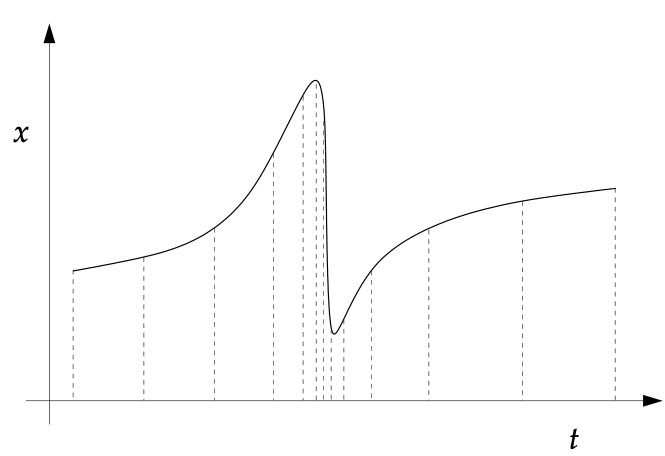

We need fine steps to resolve behavior at sharp variations, but if we have fine steps everywhere, the computation would be highly inefficient in regions of slowly varying $x$.

In adaptive stepping, we vary the step size such that the error in each step is roughly constant across the domain. 

We can estimate the error in a given step by comparing the results obtained for two consecutive steps of size $h$: 
$$ x(t) \rightarrow x(t+h) \rightarrow x(t+2h) $$ 
vs. one step of $2h$
$$ x(t) \rightarrow x(t+2h) $$

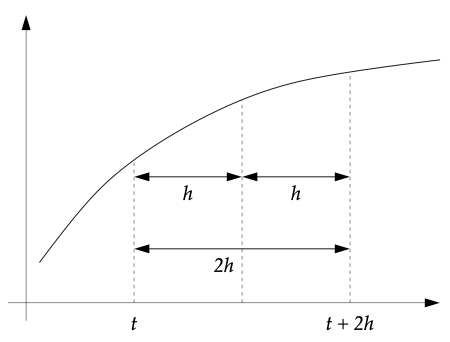

### Runge-Kutta Adaptive Error
For a 4th order scheme, the error in a single step is $\mathcal{O}(h^5)$. 

```{embed} ex_6-2
```

```{embed} sol_6-2
```

Following the derivation in Newman 8.5, by defining an optimal step size for a target accuracy **per unit time** $\delta$, we arrive at Eq. 8.52 for the optimal step size:

$$h' = h\left(\frac{30h\delta}{|x_1 - x_2|}\right)^{1/4} = h\rho^{1/4}$$

where $\rho$ is the ratio of the target step accuracy $\epsilon = h\delta$ and the actual accuracy for a step size of $h$:

$$\rho = \frac{30 h \delta}{|x_1 - x_2|}$$

```{note} Algorithm for RK4 Adaptive steps:
1. Perform two steps of size $h$ and one step of size $2h$ from the same starting point, which gives two estimates for $x(t+2h)$: $x_2$ and $x_1$ 

2. Use the two estimates to compute the error, compute the ratio $\rho$. 

3. If $\rho > 1$ then our current accuracy is better than the target accuracy so we keep the value of $x_1$, use the formula to get the optimal size $h’$ and move to the next step starting again with (1).

4. If $\rho < 1$ then the initial $h$ was too large, so we need to throw away the current iteration and recompute the same step, this time with $h'$ to determine $x(t+2h’)$, starting again with (1).

* A common rule of thumb is to never let h’ change by more than a factor of two between steps
```

```{warning} Placing limits on $h'$
:class: dropdown
+ With some bad luck, $x_1$ may be to close to $x_2$,  making $h’$ infinite or close to infinite. 
    $\rightarrow$ Place an upper limit on h’ so that it is ignored if it's too large
```

 Can also do adaptive stepping with systems of ODEs, just need more careful evaluation of how we define the error and target accuracy. Many ODE solvers consider the sum of the square of the errors of different variables, but you may also set different **tolerances** for each variable in order to focus on the variable of most interest in some situations. (More on this later)




## Second Order ODEs
Many processes in physics (waves, diffusion, etc.) can be modeled with second order differential equations of the form:

$$\frac{d^{2}x}{dt^{2}} = f\left(x, \frac{dx}{dt}, t\right)$$

We can solve these by recasting the equation, defining a new varaiable $y = \frac{dx}{dt}$, such that we now have a system of two first order differential equations:
$$\frac{dy}{dt} = f(x,y,t) ; \ \  \frac{dx}{dt} = y(x,t)$$

Which we know how to solve! (We can apply this trick recursively to higher order equations as well.)

```{note} 2nd order ODEs in vector form
Generalized to more than one dependent variable in vector form:
:class: dropdown

$$ \frac{d^{2} {\bf{r}}}{dt} =f\left( {\bf r},\frac{d{\bf r}}{dt},t \right);  \quad \frac{d{\bf r}}{dt}={\bf s}; \quad \frac{d{\bf s}}{dt}=f\left({\bf r},{\bf s},t \right) $$
```

### Ex: Orbit Around the Sun
Trajectories are a classic example of solving second order coupled ODEs.

To calculate the orbit trajectory of a secondary mass $m$ about a primary mass $M$, where $m \ll M$ in a circular planar orbit, we need to solve for the position vector over time:
$${\bf r}(t) = (x(t),y(t))$$ 

The rate of change of position is set by the velocity:
$$ \dot{\bf r}(t) = {\bf v}(t) = (u(t),v(t))$$

The equation of motion set by the balance of forces: ${\bf F} = m {\bf a} = {\bf F}_g$:
$$ \ddot{\bf r}(t) = \dot{\bf v}(t) = -\frac{GM}{r^3} {\bf r} $$



For a circular orbit, Kepler's law tells us that that relationship between the period $P$ and the distance $r$ of $m$ from $M$ is:
$$4\pi^2 r^3 = GM P^2$$

If $ M = 1  M_{\odot} $, $ r = 1 \ \mathrm{au} $, $ P = 1 \ \mathrm{yr}. $ (The Earth's orbit about the Sun)

This provides a convenient unit system in which:

$$ GM = 4 \pi^2 \ \mathrm{au^3 \ yr^{-2}} $$

Since we have multiple vectors that we will need to update over time, now is a good time to think about more advanced data structures. Let's store the information about all relevant vectors using a `class` object we'll call `State` that stores the current orbital state. 
We define `class` objects in terms of their `attributes`. By defining the `__init__` function, we decide what attributes an object has and how we'll assign them when we first call the object. 
We can use this class to set the initial conditions. 
Let's set up a planet at $1 \ \mathrm{au}$:
$${\bf r}_0 = (x_0,y_0) = (0,1)$$
with initial keplerian velocity tangential to our position:
$${\bf v}_0 = (-\sqrt{GM/r_0}, 0)$$

In this way, class objects are good ways to organize data in vector form as `State` here essentially lets you access the elements of some state vector ${\bf s} = (x, y, u , v)$

In [5]:
from math import pi,sqrt
GM = 4 * pi**2 

class State:
    def __init__(self, x, y, u, v):
        self.x = x
        self.y = y
        self.u = u
        self.v = v

    def __str__(self):
        return f"x ={self.x:10.6f} y ={self.y:10.6f} u ={self.u:10.6f} v ={self.v:10.6f}"

state0 = State(0,1,-sqrt(GM/1),0)
print(state0)

x =  0.000000 y =  1.000000 u = -6.283185 v =  0.000000


Note: that the computed initial velocity is $2 \pi \ \mathrm{au /yr}$, which nicely tracks onto tracing out a circumference of a circle $C = 2\pi r$ of $1 \ \mathrm{au}$ in radius over the course of a year.

Now, we know that in order to advance our system, we'll need to define the ODEs we'll be solving. For this we can set up a method for the  `State` object that computes the ODEs for $\dot{\bf s} = \dot{x}, \dot{y}, \dot{u}, \dot{v}$ based on what the current attributes are for the `State` object. 


In [11]:
def rhs(state):
    """
    Given a State object, computes and returns the right hand side of the ODEs for xdot, ydot, udot, and vdot
    """
    # current magnitude of radius vector
    r = sqrt(state.x**2 + state.y**2)

    # position ODE
    xdot = state.u
    ydot = state.v

    # velocity ODE
    udot = -GM*state.x/r**3
    vdot = -GM*state.y/r**3
    
    return xdot, ydot, udot, vdot



# Note that we can also assign the output of rhs into a new `state object` by unpacking:

dot_state0 = State(*rhs(state0))

print(dot_state0)

x = -6.283185 y =  0.000000 u = -0.000000 v =-39.478418


```{tip} * operator
:class: dropdown
A return statement with multiple values returns a tuple, which Python interprets as a single object. 
If we want the output to be interpreted as multiple objects without directly assigning, we can to use `*`  to "unpack" the contents of a tuple as separate elements. 

This is very handy when you want to feed the results of a function straight into another function that might be expecting multiple objects.
```

Since the Euler method essentially takes the derivative multiplied by the timestep to compute the new value as a sum:
$$ {\bf s}_{i+1} = {\bf s}_i + \Delta t  \ \dot{{\bf s}_i} $$

It would be helpful to define a function for some vector operations, like addition and multiplication. 
We'll also make the function a [*getter* and a *setter*](https://realpython.com/python-getter-setter/) (i.e. it gets attributes of an object and sets new values at the same time)


In [14]:
def add_(s1,s2):
    s1.x += s2.x
    s1.y += s2.y
    s1.u += s2.u
    s1.v += s2.v

def mult_(state, value):
    state.x *= value
    state.y *= value
    state.u *= value
    state.v *= value
    return state

state0 = State(0,1,-sqrt(GM/1),0)
print(state0)
add_(state0,mult_(dot_state0,0.1))
print(state0)

x =  0.000000 y =  1.000000 u = -6.283185 v =  0.000000
x = -0.062832 y =  1.000000 u = -6.283185 v = -0.394784


<h2><span class="fa fa-flash"></span> In-Class Coding Exercise </h2>

```{embed} icc_6-4
```

```{note} Other Implementations
:class: dropdown
Of course, using classes is the not the only way to represent this vector operation (we are just going to practice with them today in-class)

You can also set up the same function, but assuming an input array to the `rhs` function:

````{code-block} python

def rhs(vec):
    """
    for a vector computes and returns the right hand side of the ODEs for xdot, ydot, udot, and vdot as a vector array
    """
    x,y,u,v = vec 
    # current magnitude of radius vector
    r = sqrt(x**2 + y**2)

    # position ODE
    xdot = u
    ydot = v

    # velocity ODE
    udot = -GM*x/r**3
    vdot = -GM*y/r**3
    
    return np.array([xdot, ydot, udot, vdot])

````
```

## Euler-Cromer Method
You might notice that for this particular coupled ODE system, the forward Euler method didn't quite converge even for fairly small timesteps. When we compute just one orbit, taking $10^4$ timesteps might work, but often orbital dynamics problems require computing for at least hundreds of orbits! We accumulate error at each step, so very quickly we might actually lose accuracy!

Equations of motion lend themselves to a modification of the Euler method, called the [Euler-Cromer](https://en.wikipedia.org/wiki/Semi-implicit_Euler_method). This method is *semi-implicit*, in which the update order of the algorithm goes as:

$$ {\bf v}_{i+1} = {\bf v}_i + \Delta t \ \dot{\bf v}_i \\
{\bf r}_{i+1} = {\bf r}_i + \Delta t \ {\bf v}_{\color{teal} i+1} $$

Note that here the change is that the update of position uses the information for the velocity computed for the  **next** timestep.

```{note} Explicit vs. Implicit
:class: dropdown
So far, we've used **explicit** methods:  
algorithms which iterate forward in time based on information from the current timestep, like those of the form:
$$ x_{i+1} = x_i + \dot{x}_i \Delta t$$
**implicit** methods:  
pose the problem in which the information for the update comes from the next timestep, like for example:
$$ x_{i+1} - \dot{x}_{i+1} \Delta t = x_i $$
in which the solution at the next timestep is now the solution for a quadratic function in $x_{i+1}$. 

See: [Example for forward vs. backward Euler](https://en.wikipedia.org/wiki/Explicit_and_implicit_methods#Illustration_using_the_forward_and_backward_Euler_methods)
```





<h2><span class="fa fa-flash"></span> In-Class Coding Exercise </h2>

```{embed} icc_6-5
```